# IMDB Sentiment Classification using LSTM



The goal of this model is to improve the performance obtained in Assignment 1 
by using a deep learning approach that works directly on text sequences.


# Import Required Libraries

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

from sklearn.metrics import classification_report, accuracy_score

# Load IMDB Dataset

In [ ]:

num_words = 10000  # top most frequent words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000
Testing samples: 25000


In [67]:
print("Example review (encoded):", X_train[0])
print("Label:", y_train[0])  # 1 = positive, 0 = negative

Example review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Label: 1


# Pad Sequences for LSTM Input

In [68]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("Shape after padding:", X_train.shape)

Shape after padding: (25000, 200)


# Build LSTM Model Architecture

In [69]:
model = Sequential()

model.add(Embedding(input_dim=num_words, output_dim=128, input_length=max_len))
model.add(LSTM(128))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

In [70]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train the Model


In [71]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 103s 321ms/step - accuracy: 0.7588 - loss: 0.4855 - val_accuracy: 0.8466 - val_loss: 0.3619
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 315ms/step - accuracy: 0.8856 - loss: 0.2846 - val_accuracy: 0.8356 - val_loss: 0.3722
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 305ms/step - accuracy: 0.9260 - loss: 0.1978 - val_accuracy: 0.8728 - val_loss: 0.3239
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 318ms/step - accuracy: 0.9446 - loss: 0.1532 - val_accuracy: 0.8714 - val_loss: 0.3900
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 304ms/step - accuracy: 0.9462 - loss: 0.1448 - val_accuracy: 0.8548 - val_loss: 0.4876


# Evaluate Model Performance


In [72]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.8515 - loss: 0.5050
Test Accuracy: 0.8514800071716309


# Generate Predictions

In [73]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step


# Classification Report

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84     12500
           1       0.82      0.89      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



# Plot Training and Validation Accuracy

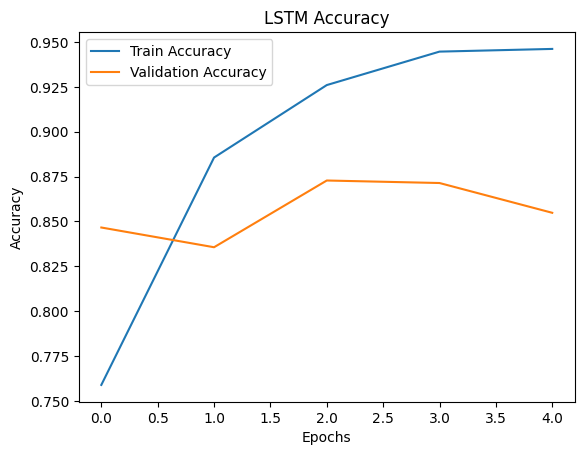

In [77]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("LSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.savefig("lstm_accuracy.png")  # saves file
plt.show()

# Plot Training and Validation Loss

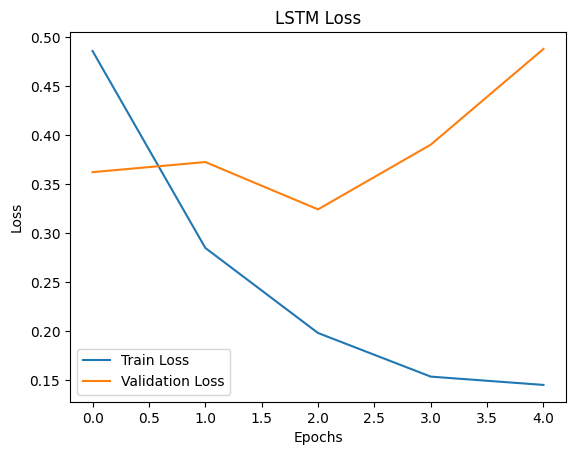

In [78]:
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("LSTM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.savefig("lstm_loss.png")  # saves file
plt.show()